In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

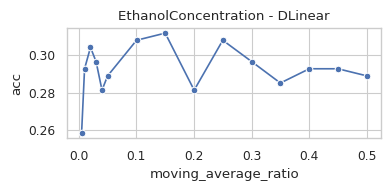

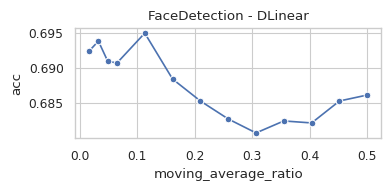

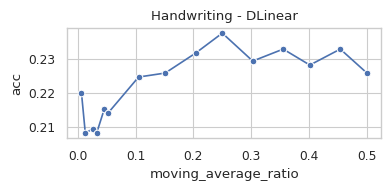

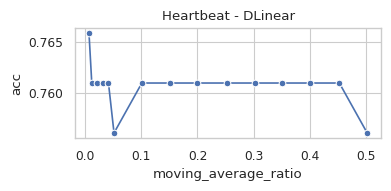

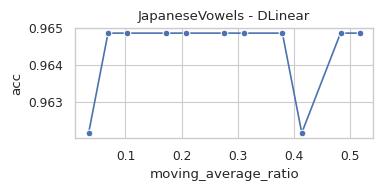

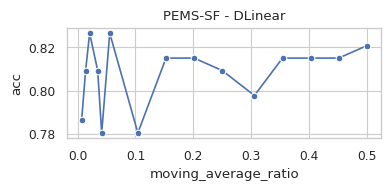

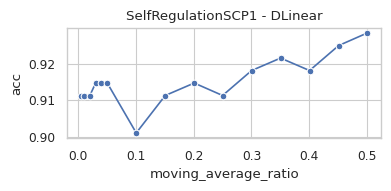

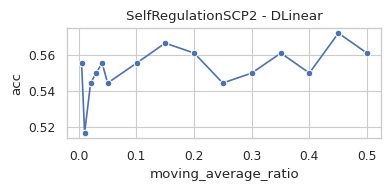

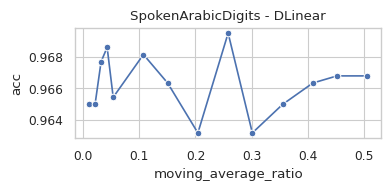

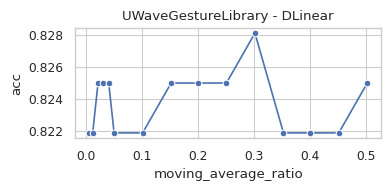

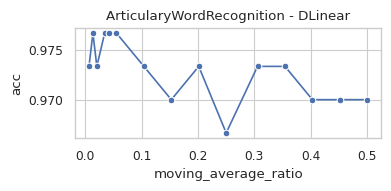

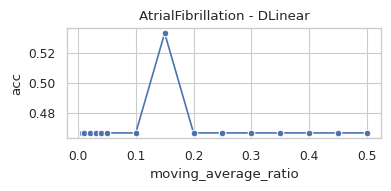

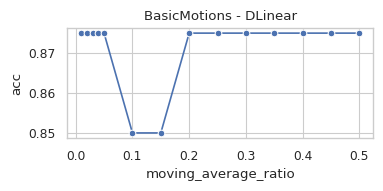

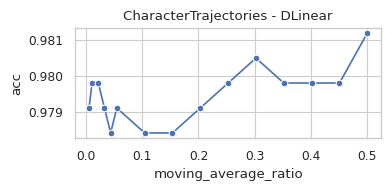

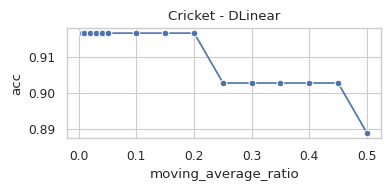

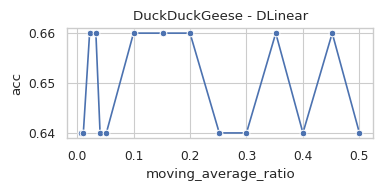

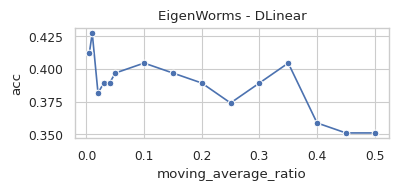

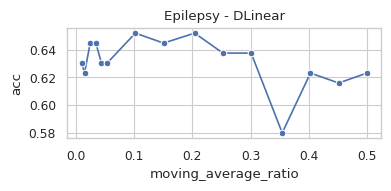

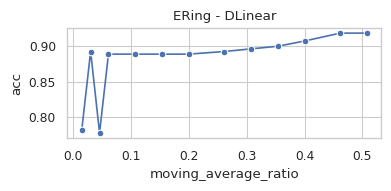

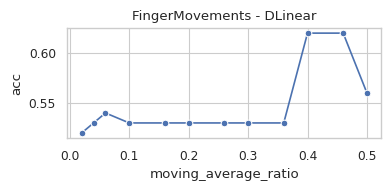

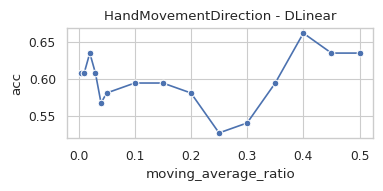

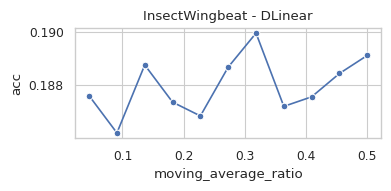

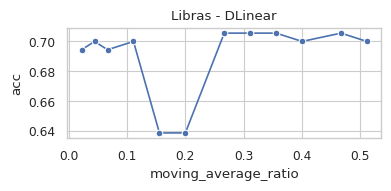

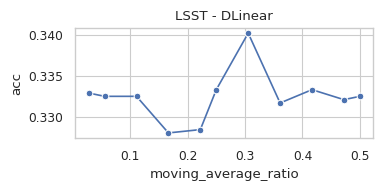

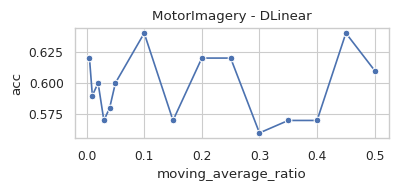

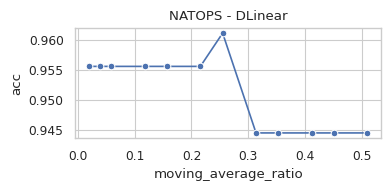

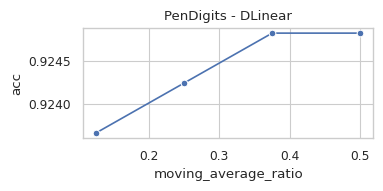

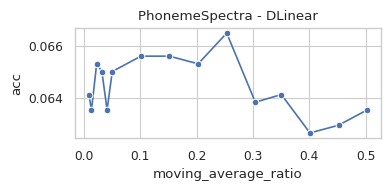

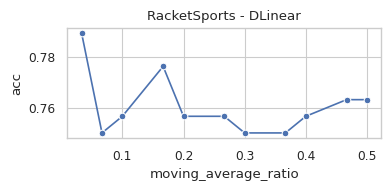

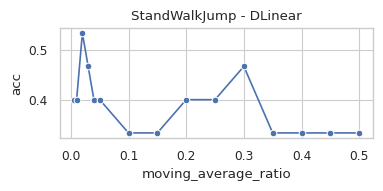

In [3]:
model = 'DLinear'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('ma', ''))
            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'model_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'moving_average': data_meta[9],
                'moving_average_ratio': data_meta[9] / data_meta[6],
                # 'exp': data_meta[11],
                # 'desc': data_meta[12],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df

    col = 'moving_average_ratio'
    
    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig = plt.figure(figsize=(4, 2))
    ax = sns.lineplot(x=col, y='acc', data=result_df, legend=False, markers=True, style='model')
    ax.set_title(f'{data_name} - {model}')
    ax.set_xlabel(col)
    plt.tight_layout()
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    

In [4]:
model_configs = {
    "moving_avg_ratio" : [0.5, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],  
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30)
for data_name in UEA_MTSC30:
    for hyperparameter_combination in hyperparameter_combinations:
        moving_avg_ratio = hyperparameter_combination['moving_avg_ratio']

        if result_dict.get(data_name) is None:
            continue
        
        tmp = result_dict[data_name]
        try:
            acc = tmp[
                tmp['moving_average'] == math.ceil(tmp["seq_len"].values[0] * (moving_avg_ratio/100))
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with moving_avg_ratio {moving_avg_ratio}')
        acc_all_df.loc[data_name, str(hyperparameter_combination)] = acc



In [5]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,{'moving_avg_ratio': 2},{'moving_avg_ratio': 45},{'moving_avg_ratio': 3},{'moving_avg_ratio': 40},{'moving_avg_ratio': 50},{'moving_avg_ratio': 10},{'moving_avg_ratio': 20},{'moving_avg_ratio': 5},{'moving_avg_ratio': 15},{'moving_avg_ratio': 30},{'moving_avg_ratio': 25},{'moving_avg_ratio': 0.5},{'moving_avg_ratio': 1},{'moving_avg_ratio': 35},{'moving_avg_ratio': 4}
EthanolConcentration,0.311787,0.304183,0.292776,0.296578,0.292776,0.288973,0.307985,0.281369,0.288973,0.311787,0.296578,0.307985,0.258555,0.292776,0.285171,0.281369
FaceDetection,0.694949,0.693814,0.685301,0.693814,0.682179,0.686152,0.694949,0.685301,0.690692,0.688422,0.680760,0.682747,0.692395,0.692395,0.682463,0.690976
Handwriting,0.237647,0.209412,0.232941,0.208235,0.228235,0.225882,0.224706,0.231765,0.214118,0.225882,0.229412,0.237647,0.220000,0.208235,0.232941,0.215294
Heartbeat,0.765854,0.760976,0.760976,0.760976,0.760976,0.756098,0.760976,0.760976,0.756098,0.760976,0.760976,0.760976,0.765854,0.760976,0.760976,0.760976
JapaneseVowels,0.964865,0.962162,0.964865,0.962162,0.962162,0.964865,0.964865,0.964865,0.964865,0.964865,0.964865,0.964865,0.962162,0.962162,0.964865,0.964865
PEMS-SF,0.826590,0.826590,0.815029,0.809249,0.815029,0.820809,0.780347,0.815029,0.826590,0.815029,0.797688,0.809249,0.786127,0.809249,0.815029,0.780347
SelfRegulationSCP1,0.928328,0.911263,0.924915,0.914676,0.918089,0.928328,0.901024,0.914676,0.914676,0.911263,0.918089,0.911263,0.911263,0.911263,0.921502,0.914676
SelfRegulationSCP2,0.572222,0.544444,0.572222,0.550000,0.550000,0.561111,0.555556,0.561111,0.544444,0.566667,0.550000,0.544444,0.555556,0.516667,0.561111,0.555556
SpokenArabicDigits,0.969532,0.964984,0.966803,0.967713,0.966348,0.966803,0.968167,0.963165,0.965439,0.966348,0.963165,0.969532,0.964984,0.964984,0.964984,0.968622
UWaveGestureLibrary,0.828125,0.825000,0.821875,0.825000,0.821875,0.825000,0.821875,0.825000,0.821875,0.825000,0.828125,0.825000,0.821875,0.821875,0.821875,0.825000


In [6]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,{'moving_avg_ratio': 2}
EthanolConcentration,31.17870722433460,30.41825095057034
FaceDetection,69.49489216799091,69.38138479001135
Handwriting,23.76470588235294,20.94117647058824
Heartbeat,76.58536585365854,76.09756097560975
JapaneseVowels,96.48648648648648,96.21621621621622
PEMS-SF,82.65895953757226,82.65895953757226
SelfRegulationSCP1,92.83276450511946,91.12627986348123
SelfRegulationSCP2,57.22222222222222,54.44444444444444
SpokenArabicDigits,96.95316052751251,96.49840836743975
UWaveGestureLibrary,82.81250000000000,82.50000000000000
